<a href="https://colab.research.google.com/github/EMANFATIMA06/DATA-SCIENCE-AND-ANALYTICS-/blob/main/Term%20Deposit%20Subscription%20Prediction%20(Bank%20Marketing).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Term Deposit Subscription Prediction (Bank Marketing)***

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, f1_score, roc_curve, roc_auc_score, ConfusionMatrixDisplay)

In [ ]:
df = pd.read_csv("/content/bank-full.csv", sep=";")

In [ ]:
df.describe()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,durations,campaign,pdays,previous,poutcome,y
count,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000
mean,40.936297,4.339814,1.167728,1.224818,0.018027,1362.236474,0.555850,0.160230,0.640257,15.806392,5.522937,258.160805,2.763858,40.194559,0.580093,2.560009,0.116987
std,10.618863,3.272675,0.608236,0.748005,0.133050,3044.790103,0.496876,0.366823,0.897956,8.322566,3.006900,257.530206,3.098053,100.127440,2.302945,0.989043,0.321409
min,18.000000,0.000000,0.000000,0.000000,0.000000,-8019.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,-1.000000,0.000000,0.000000,0.000000
25%,33.000000,1.000000,1.000000,1.000000,0.000000,72.000000,0.000000,0.000000,0.000000,8.000000,3.000000,103.000000,1.000000,-1.000000,0.000000,3.000000,0.000000
50%,39.000000,4.000000,1.000000,1.000000,0.000000,448.000000,1.000000,0.000000,0.000000,16.000000,6.000000,180.000000,2.000000,-1.000000,0.000000,3.000000,0.000000
75%,48.000000,7.000000,2.000000,2.000000,0.000000,1427.750000,1.000000,0.000000,2.000000,21.000000,8.000000,319.000000,3.000000,-1.000000,0.000000,3.000000,0.000000
max,95.000000,11.000000,2.000000,3.000000,1.000000,102127.000000,1.000000,1.000000,2.000000,31.000000,11.000000,4918.000000,63.000000,871.000000,275.000000,3.000000,1.000000


In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'durations', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [ ]:
df.shape

(45210, 17)

In [ ]:
# 2. Encode categorical columns (turn text into numbers)
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
# 3. Split data into features (X) and target (y)
X = df.drop('y', axis=1)
y = df['y']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train models
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Predict
log_pred = log_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

Logistic Regression F1: 0.3064516129032258
Random Forest F1: 0.5264900662251656


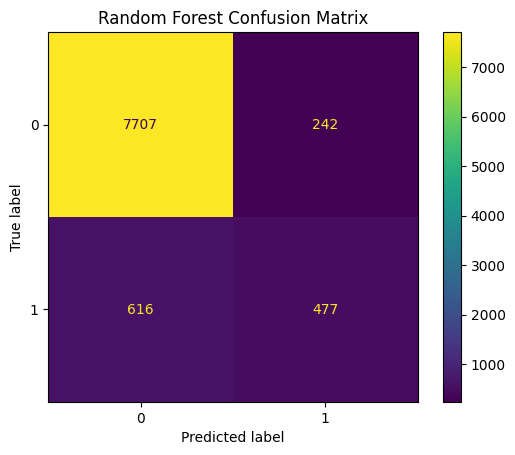

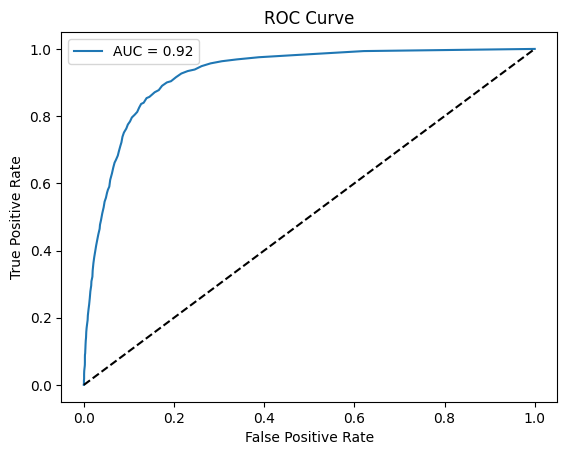

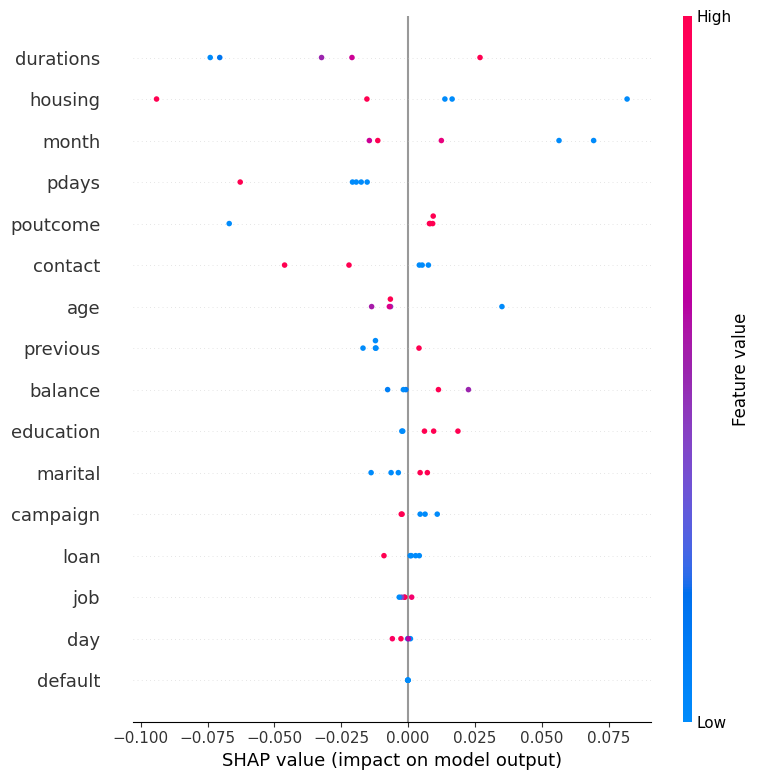

In [ ]:
# 6. Evaluate: F1 Score
print("Logistic Regression F1:", f1_score(y_test, log_pred))
print("Random Forest F1:", f1_score(y_test, rf_pred))

# 7. Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

# 8. ROC Curve
rf_probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_probs)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, rf_probs):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 9. Explain 5 predictions using SHAP
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test[:5])

shap.summary_plot(shap_values[:,:,1] if shap_values.ndim==3 else shap_values, X_test[:5], show=True)

***OBSERVATIONS:***

***F1-Score:*** Random Forest (0.526) is much stronger than Logistic Regression (0.306) — Random Forest is clearly the better model here.

***Confusion Matrix (Random Forest):***

*   7,707 "No" customers correctly identified, only 242 wrongly flagged as "Yes" — very few false alarms.
*   Of actual "Yes" customers, only 477 were correctly caught, while 616 were missed (predicted "No" but actually "Yes"). This means the model is still cautious about predicting "Yes" and misses more than half of the real subscribers.
*   Overall: strong at avoiding false positives, weaker at catching all true subscribers (recall on "Yes" is low).

***ROC Curve:*** AUC = 0.92, meaning the model separates subscribers from non-subscribers very well overall — the curve rises sharply and stays well above the random-guess diagonal.

***SHAP Plot:*** Because it's based on only 5 samples, the pattern is a bit sparse/hard to generalize, but durations, housing, and month appear to have the widest spread of impact, suggesting they influence predictions the most in this small sample. Features like loan, campaign, and marital show minimal spread, meaning they barely move the prediction.